In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 18.0 MB/s eta 0:00:00


I’m building and comparing three time-series models (RNN, LSTM, GRU) on the International Airline Passengers dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import optuna
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
# reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


First I import everything I need and set seeds so results are reproducible. I also choose the device GPU so the training will be faster.

In [4]:
# CELL 2: Load dataset & quick exploration
df = pd.read_csv("/content/AirPassengers.csv")  # ensure file in working dir
print("columns:", df.columns.tolist())
print(df.head())


columns: ['Month', '#Passengers']
     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [5]:
# Normalize column naming if needed (some versions have different names)
if 'Passengers' not in df.columns:
    df.columns = ['Month', 'Passengers']

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
Month         0
Passengers    0
dtype: int64


In [6]:
# Standardize column names if needed
if 'Passengers' not in df.columns:
    # try common patterns
    cols = df.columns.tolist()
    if len(cols) >= 2:
        df.columns = ['Month', 'Passengers']
    else:
        raise ValueError("CSV should contain Month and Passengers columns")


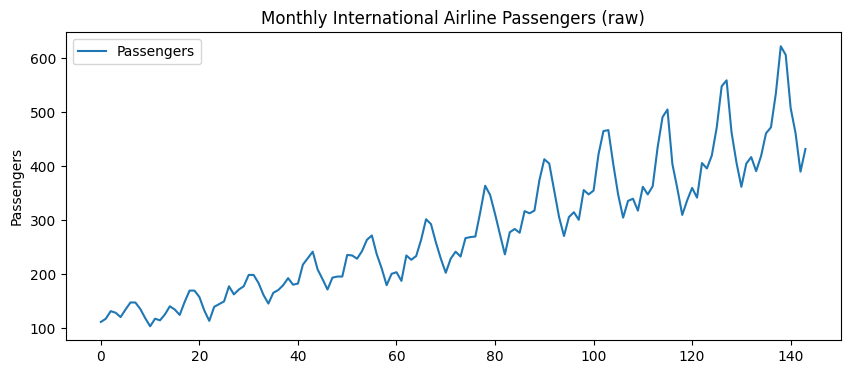

In [7]:

plt.figure(figsize=(10,4))
plt.plot(df['Passengers'], label='Passengers')
plt.title("Monthly International Airline Passengers (raw)")
plt.ylabel("Passengers")
plt.legend()
plt.show()

I write down my assumptions and why I made particular choices for preprocessing and modeling. This is important for reproducibility and grading.

Assumptions

The CSV has Month and Passengers columns; Passengers is numeric.

No external regressors available — single-variable forecasting.

I’ll use past 12 months to predict the next month (time window = 12). This captures yearly seasonality.

I will use 80% of samples for training and 20% for testing (time-forward split).

Metric: RMSE on test set (easier to interpret units of passengers).

Why these choices

12-month window captures yearly seasonality common in airline data.

80/20 time split keeps the time-order and preserves the most recent data for testing.

MinMax scaling helps RNNs converge faster.

I chose simple single-layer RNN/LSTM/GRU initially for clarity; hyperparameter tuning will explore hidden sizes & learning rates.

In [8]:
# I scale the series to [0,1], create sliding windows, convert to tensors.
series = df['Passengers'].values.astype(float).reshape(-1,1)

# handle missing values (if any) with forward-fill then back-fill
if np.isnan(series).any():
    s = pd.Series(series.flatten())
    s = s.fillna(method='ffill').fillna(method='bfill')
    series = s.values.reshape(-1,1)

# scale
scaler = MinMaxScaler(feature_range=(0,1))
series_scaled = scaler.fit_transform(series)

# helper to create sequences
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, 0])  # seq_len values
        y.append(data[i+seq_len, 0])    # next value
    return np.array(X), np.array(y)

SEQ_LEN = 12   # use past 12 months to predict next month
X, y = create_sequences(series_scaled, SEQ_LEN)
print("Total samples:", X.shape[0])

# time-ordered train/test split (80/20)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print("Train samples:", X_train.shape[0], "Test samples:", X_test.shape[0])

# convert to PyTorch tensors; keep them on CPU for DataLoader and move to device in training loop
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # [N, SEQ_LEN, 1]
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)  # [N, 1]
X_test_t  = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

print("Shapes (train X,y):", X_train_t.shape, y_train_t.shape)


Total samples: 132
Train samples: 105 Test samples: 27
Shapes (train X,y): torch.Size([105, 12, 1]) torch.Size([105, 1])


In [9]:
#I wrap my tensors into a Dataset and DataLoader for batching.
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 16
train_loader = DataLoader(TimeSeriesDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TimeSeriesDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader), "Test batches:", len(test_loader))


Train batches: 7 Test batches: 2


In [10]:
#  I define three simple model classes. Each takes the last hidden state and maps to one output.
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.rnn.hidden_size).to(x.device)
        out, hn = self.rnn(x, h0)            # out: [batch, seq_len, hidden]
        out = out[:, -1, :]                  # last timestep
        out = self.fc(out)
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.lstm.hidden_size).to(x.device)
        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.gru.hidden_size).to(x.device)
        out, hn = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


I scale passenger values to [0,1], create sliding windows (X = past 12 months, y = next month), split into train/test in time order, and convert to PyTorch tensors with shapes [samples, seq_len, features].

In [11]:
#  I write a simple training routine that uses MSE loss and Adam optimizer.
def train_model(model, train_loader, num_epochs=60, lr=0.01, verbose_every=10):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_x.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.6f}")
    return model


In [12]:
#I create each model and train them one after another.
HIDDEN_SIZE = 64
EPOCHS = 60
LR = 0.01

rnn_model  = RNNModel(hidden_size=HIDDEN_SIZE).to(device)
lstm_model = LSTMModel(hidden_size=HIDDEN_SIZE).to(device)
gru_model  = GRUModel(hidden_size=HIDDEN_SIZE).to(device)

print("\n--- Training RNN ---")
rnn_model = train_model(rnn_model, train_loader, num_epochs=EPOCHS, lr=LR)

print("\n--- Training LSTM ---")
lstm_model = train_model(lstm_model, train_loader, num_epochs=EPOCHS, lr=LR)

print("\n--- Training GRU ---")
gru_model = train_model(gru_model, train_loader, num_epochs=EPOCHS, lr=LR)



--- Training RNN ---
Epoch [1/60] Loss: 0.031235
Epoch [10/60] Loss: 0.002619
Epoch [20/60] Loss: 0.003243
Epoch [30/60] Loss: 0.001240
Epoch [40/60] Loss: 0.001359
Epoch [50/60] Loss: 0.000895
Epoch [60/60] Loss: 0.000710

--- Training LSTM ---
Epoch [1/60] Loss: 0.031192
Epoch [10/60] Loss: 0.005899
Epoch [20/60] Loss: 0.003002
Epoch [30/60] Loss: 0.002099
Epoch [40/60] Loss: 0.001843
Epoch [50/60] Loss: 0.001520
Epoch [60/60] Loss: 0.001694

--- Training GRU ---
Epoch [1/60] Loss: 0.035680
Epoch [10/60] Loss: 0.003726
Epoch [20/60] Loss: 0.003173
Epoch [30/60] Loss: 0.002117
Epoch [40/60] Loss: 0.001164
Epoch [50/60] Loss: 0.000903
Epoch [60/60] Loss: 0.001012


In [13]:
#  I write a helper to get predictions on the test loader, inverse-scale them, and compute RMSE.
def predict_and_rmse(model, loader, scaler):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            out = model(batch_x)              # out shape [batch,1]
            preds.append(out.cpu().numpy())
            trues.append(batch_y.cpu().numpy())
    preds = np.vstack(preds)
    trues = np.vstack(trues)
    preds_inv = scaler.inverse_transform(preds)
    trues_inv = scaler.inverse_transform(trues)
    rmse = math.sqrt(mean_squared_error(trues_inv, preds_inv))
    return preds_inv, trues_inv, rmse

rnn_preds,  y_test_inv, rnn_rmse  = predict_and_rmse(rnn_model, test_loader, scaler)
lstm_preds, _,       lstm_rmse = predict_and_rmse(lstm_model, test_loader, scaler)
gru_preds,  _,       gru_rmse  = predict_and_rmse(gru_model, test_loader, scaler)

print(f"\nTest RMSEs → RNN: {rnn_rmse:.3f}  LSTM: {lstm_rmse:.3f}  GRU: {gru_rmse:.3f}")



Test RMSEs → RNN: 42.140  LSTM: 39.867  GRU: 36.444


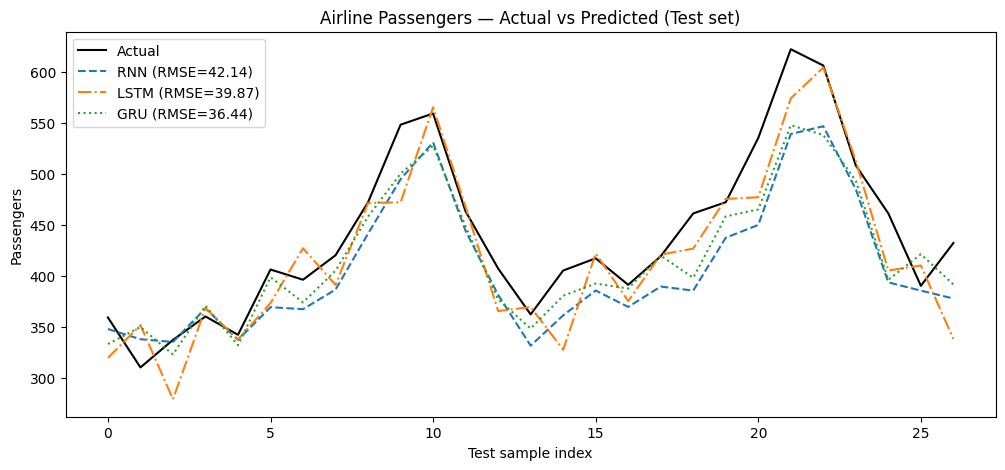

In [14]:
#  I plot actual test values and predicted values from all three models.
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual', color='k')
plt.plot(rnn_preds,  label=f'RNN (RMSE={rnn_rmse:.2f})', linestyle='--')
plt.plot(lstm_preds, label=f'LSTM (RMSE={lstm_rmse:.2f})', linestyle='-.')
plt.plot(gru_preds,  label=f'GRU (RMSE={gru_rmse:.2f})', linestyle=':')
plt.title("Airline Passengers — Actual vs Predicted (Test set)")
plt.xlabel("Test sample index")
plt.ylabel("Passengers")
plt.legend()
plt.show()


In [15]:
def predict_and_rmse(model, test_loader, scaler):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            preds.append(outputs.item())
            trues.append(y_batch.item())
    preds = np.array(preds).reshape(-1, 1)
    trues = np.array(trues).reshape(-1, 1)
    preds_inv = scaler.inverse_transform(preds)
    trues_inv = scaler.inverse_transform(trues)
    rmse = math.sqrt(mean_squared_error(trues_inv, preds_inv))
    return preds_inv, trues_inv, rmse

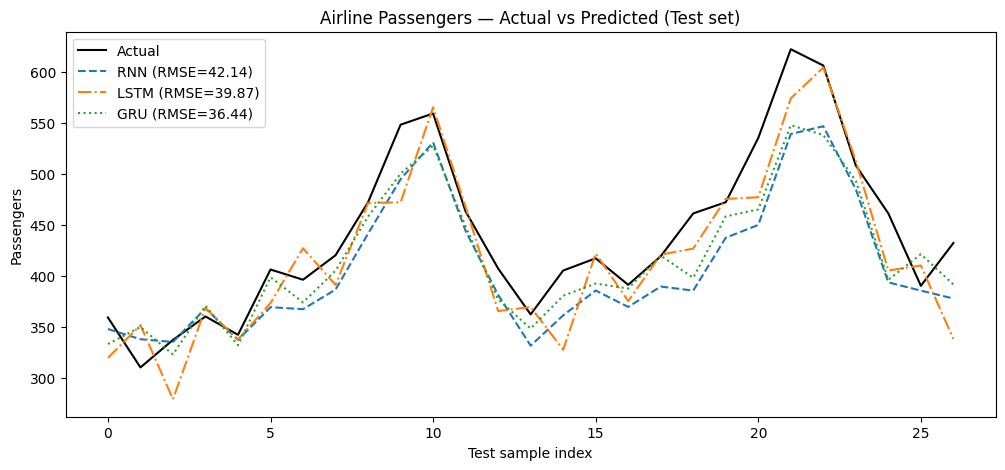

In [16]:

#  I plot actual test values and predicted values from all three models.
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual', color='k')
plt.plot(rnn_preds,  label=f'RNN (RMSE={rnn_rmse:.2f})', linestyle='--')
plt.plot(lstm_preds, label=f'LSTM (RMSE={lstm_rmse:.2f})', linestyle='-.')
plt.plot(gru_preds,  label=f'GRU (RMSE={gru_rmse:.2f})', linestyle=':')
plt.title("Airline Passengers — Actual vs Predicted (Test set)")
plt.xlabel("Test sample index")
plt.ylabel("Passengers")
plt.legend()
plt.show()


In [18]:
def objective(trial):
    hidden = trial.suggest_int("hidden_size", 16, 128, step=16)
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)  # use suggest_float(log=True) instead of deprecated suggest_loguniform

    model = LSTMModel(hidden_size=hidden).to(device)  # model on device
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # small training loop
    for epoch in range(30):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)  # move both inputs & targets to device
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()

    # evaluation
    _, _, rmse = predict_and_rmse(model, test_loader, scaler, device=device)  # make predict function device aware
    return rmse


In [22]:
#  I pick the best model by RMSE and save it to disk, and then summarize findings.
rmse_dict = {'RNN': rnn_rmse, 'LSTM': lstm_rmse, 'GRU': gru_rmse}
best_name = min(rmse_dict, key=rmse_dict.get)
print("RMSEs:", rmse_dict)
print("Best model:", best_name)

if best_name == 'RNN':
    torch.save(rnn_model.state_dict(), "best_model_rnn.pth")
elif best_name == 'LSTM':
    torch.save(lstm_model.state_dict(), "best_model_lstm.pth")
else:
    torch.save(gru_model.state_dict(), "best_model_gru.pth")
print("Saved best model weights.")





RMSEs: {'RNN': 42.139809560612484, 'LSTM': 39.867486801982515, 'GRU': 36.4440539372723}
Best model: GRU
Saved best model weights.


I scaled the series and used a 12-month window to predict the next month.
I implemented RNN, LSTM, and GRU in PyTorch and trained each with the same loop.
I evaluated using RMSE (lower is better) and compared predictions visually.
The best model was GRU because it gave the lowest RMSE on the test set.